### ベンチマーク概要
HBase(2.0.1), MongoDB(4.0), Cassandra(3.11.2)を対象にしたYCSB(Yahoo Cloud Service Benchmark)を使用したベンチマークテスト
#### クラスタ容量
- ワーカー (データ) ノード: 3
- ワーカー (データ) インスタンス: m5.4xlarge 16 vCPU 64G RAM SSD 500G
- ディスク容量: 1.5TB (500GB * 3)
- RAM: 192GB (64GB * 3)

#### HBase構成
- Masterインスタンスは、m5.2xlarge 8 vCPU 32G RAM SSD 50G

|-|Master|Slave0| Slave1|Slave2|
|:---:|:---:|:---:|:---:|:---:|
|NameNode|○|-|-|-|
|DataNode|-|○|○|○|
|HMaster|○|-|-|-|
|Master Backup |-|○|-|-|
|Resion Server|-|○|○|○|
|Zookeeper|○|-|-|-|

#### MongoDB構成
- Routerインスタンスは、m5.2xlarge 8 vCPU 32G RAM SSD 50G
- Secondaryのmongodを上げるとIO負荷でデータロードが終わらなかったのでレプリケーション無し

|-|Router|Shard Server0|Shard Server1|Shard Server2|
|:---:|:---:|:---:|:---:|:---:|
|mongos|○|-|-|-|
|mongoc|○|-|-|-|
|mongod (rs0)|-|Primary|-|-|
|mongod (rs1)|-|-|Primary|-|
|mongod (rs2)|-|-|-|Primary|

#### Cassandra構成
|-|Node0|Node2|Node3|
|:---:|:---:|:---:|:---:|
|Seed|○|-|-|
|Normal|-|○|○|

#### データ
- 件数: 3億
- レプリケーション数: 3 ※
- サイズ: 300G程度 (レプリカを含め1TB弱)
- データ圧縮: 全データベースSnappy

#### ワークロード
各ワークロード合計100万オペレーション、スループットとレイテンシを計測

|ワークロード名|タイトル|シナリオ内容|想定アプリケーション例|
|:---|:---|:---|:---|
|Workload A|Update heavy workload|Read 50% / Update 50%|最近のアクションを記録するセッションストア|
|Workload B|Read mostly workload|Read 95% / Update 5%|写真へのタグ付け。タグの追加は更新だが、ほとんどがタグの読み取り|
|Workload C|Read only|Read 100%|ユーザ設定のキャッシュ|
|Workload D|Read latest workload|Read 95% / Insert 5%|ユーザの近況アップデート。新しいものほどよく読まれる|
|Workload E|Medium ranges|Scan 95% / Insert 5% Scan Length: 10,000|データ分析時のシーケンシャルなデータ読み込み|
|Workload F|Read-modify-write|Read 50% / Read Modify Write 50%|ユーザ情報のデータベース|

### 結果外観
- HBaseが全てのワークロードで安定して高いパフォーマンス、UPDATEが比較的苦手
- MongoDBは、データロードで苦戦したがスキャン（シーケンシャルアクセス）を除くトランザクションの多くで最高性能、ただし今回はレプリカをおいていない
- Cassandraは、データロードで圧倒的なパフォーマンスを見せたが、それ以外のオンライン系トランザクションの結果はいまいち。スキャンは思ったほど悪くないパフォーマンス。※途中で1ノード落ちたので要再テスト

以下、ワークロードごとの結果

### データロード
- 3億レコード (usertable) のロード (ベンチデータ準備) 処理
- Cassandraが一番高いスループットを出した、HBaseも十分に高く安定したスループット
- MongoDBは、書き込みがキャッシュにのっているうちは良かったが、キャッシュの利用率80%に達したぐらいから徐々に不安定に。。。

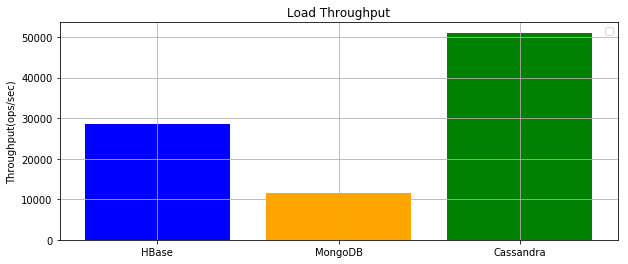

[28638.841677228036, 11495.761857476004, 51047.850723833]

In [8]:
y = plot_throughput_bar(hbase_load_log, mongo_load_log, cassa_load_log)
y

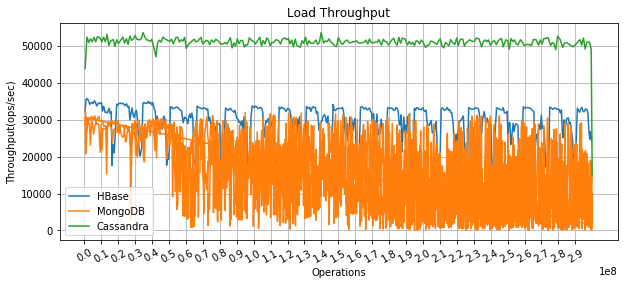

In [9]:
plot_throughput_timeline(hbase_load_log, mongo_load_log, cassa_load_log)

### ワークロードA
Read 50% / Update 50%

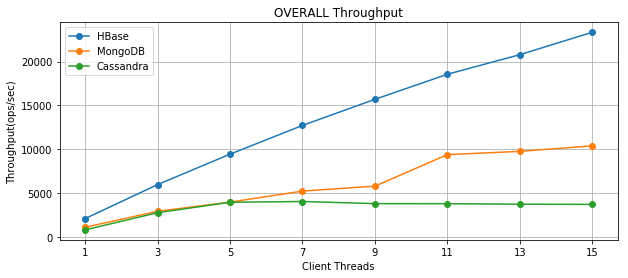

,Cassandra,HBase,MongoDB
1,794.812734,2082.812630,1091.389699
3,2757.008315,5961.180791,2918.174390
5,3948.090506,9432.538485,3962.734445
7,4035.317095,12711.487371,5221.005148
9,3793.972137,15692.428403,5788.980097
11,3785.770802,18547.369983,9384.032131
13,3729.603730,20783.107490,9753.813741
15,3705.968462,23339.946318,10383.353408


In [10]:
df = plot_overall_throughput(hbase_workloada_log, mongo_workloada_log, cassa_workloada_log)
df

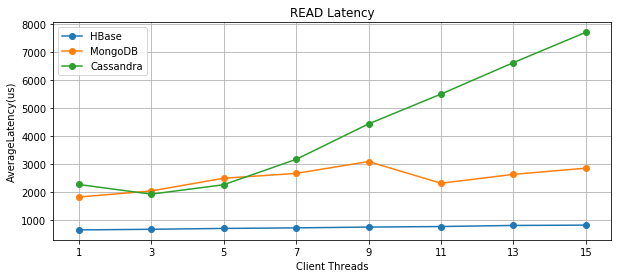

,Cassandra,HBase,MongoDB
1,2269.131078,645.262748,1821.056036
3,1924.263848,667.976808,2037.245701
5,2259.425914,698.538187,2492.084328
7,3166.351690,718.220513,2664.855456
9,4433.800206,747.446853,3088.255725
11,5500.455593,766.186650,2313.537345
13,6625.103258,805.388644,2630.996636
15,7709.494266,816.405038,2851.777077


In [11]:
df = plot_latency(hbase_workloada_log, mongo_workloada_log, cassa_workloada_log, ops='READ')
df

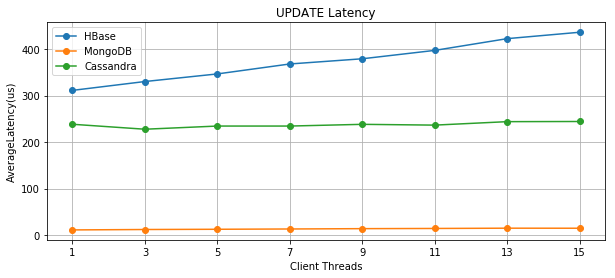

,Cassandra,HBase,MongoDB
1,238.298546,311.154629,11.132048
3,227.631230,330.173968,12.001172
5,234.451247,346.542074,12.525884
7,234.451681,367.934472,13.129418
9,238.147725,379.107788,13.846096
11,236.454861,397.150335,14.257156
13,243.912216,422.401773,14.855461
15,244.248893,436.151251,14.737501


In [12]:
df = plot_latency(hbase_workloada_log, mongo_workloada_log, cassa_workloada_log, ops='UPDATE')
df

### ワークロードB
Read 95% / Update 5%

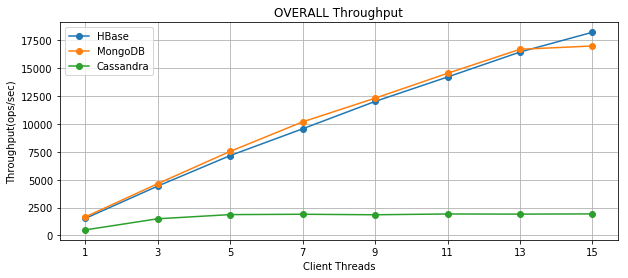

,Cassandra,HBase,MongoDB
1,498.135479,1524.118412,1658.465554
3,1495.161657,4424.445949,4639.617696
5,1870.550428,7160.964152,7535.851815
7,1901.661291,9560.595051,10183.091994
9,1857.044699,12013.455070,12304.814874
11,1926.336878,14205.352577,14535.517537
13,1914.733105,16442.770936,16690.032712
15,1933.970383,18217.259031,16985.426504


In [13]:
df = plot_overall_throughput(hbase_workloadb_log, mongo_workloadb_log, cassa_workloadb_log)
df

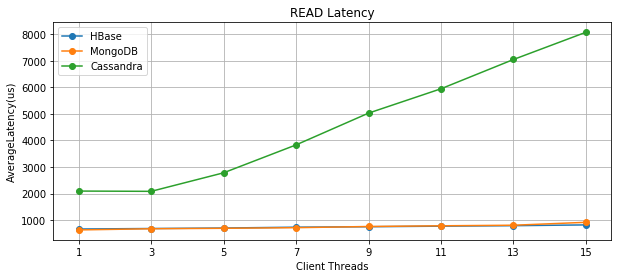

,Cassandra,HBase,MongoDB
1,2094.784556,666.060068,632.253660
3,2084.102991,685.486195,676.188496
5,2782.210976,703.482607,693.669019
7,3833.039852,735.184112,716.074725
9,5028.859194,751.864547,760.970321
11,5945.526664,773.704375,787.279274
13,7047.665448,791.439884,808.940987
15,8072.698520,821.113739,918.207968


In [14]:
df = plot_latency(hbase_workloadb_log, mongo_workloadb_log, cassa_workloadb_log, ops='READ')
df

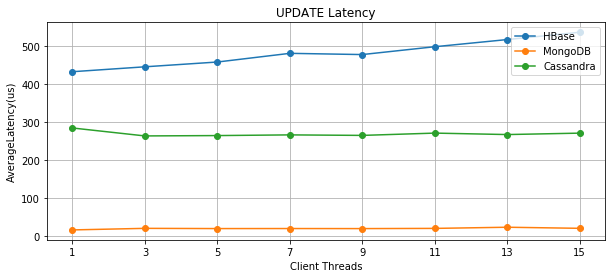

,Cassandra,HBase,MongoDB
1,284.223105,432.482410,15.625126
3,263.272354,445.412878,19.751275
5,264.212809,458.034026,19.151283
7,266.021935,480.896121,19.245961
9,264.678804,477.665402,19.100467
11,270.714728,498.323321,19.633747
13,266.887275,517.215531,22.694879
15,270.645925,536.479786,19.840506


In [15]:
df = plot_latency(hbase_workloadb_log, mongo_workloadb_log, cassa_workloadb_log, ops='UPDATE')
df

### ワークロードC
Read 100%

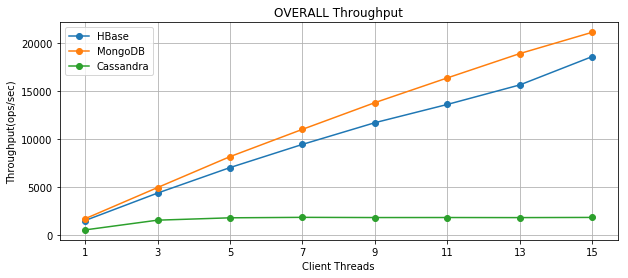

,Cassandra,HBase,MongoDB
1,514.754141,1494.696816,1681.644514
3,1531.386533,4358.096035,4932.961059
5,1777.234339,7018.381140,8159.801554
7,1825.903731,9437.345463,11008.851116
9,1804.894513,11702.339298,13794.245041
11,1807.818090,13606.738057,16375.992795
13,1799.234246,15643.087320,18914.318139
15,1817.990103,18602.574596,21137.180300


In [16]:
df = plot_overall_throughput(hbase_workloadc_log, mongo_workloadc_log, cassa_workloadc_log)
df

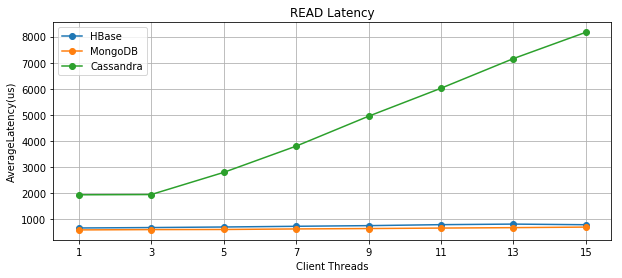

,Cassandra,HBase,MongoDB
1,1939.039605,667.278401,593.282025
3,1948.530640,683.728802,605.449298
5,2796.556578,705.048957,609.776734
7,3803.627869,732.268673,630.800256
9,4950.602619,757.275245,645.733883
11,6023.767423,794.764457,663.808176
13,7160.352731,816.240510,680.673722
15,8168.830944,792.141659,701.467726


In [17]:
df = plot_latency(hbase_workloadc_log, mongo_workloadc_log, cassa_workloadc_log, ops='READ')
df

### ワークロードD
Read 95% / Insert 5%	

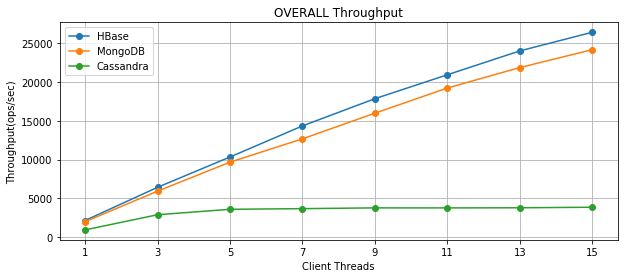

,Cassandra,HBase,MongoDB
1,920.889174,2134.489942,1976.104939
3,2879.098036,6415.890879,5920.452796
5,3579.162118,10326.204810,9657.636776
7,3664.251925,14335.684386,12667.046678
9,3762.807657,17847.581653,15978.269553
11,3758.988682,20932.325791,19224.114730
13,3775.864673,24010.180316,21861.268391
15,3847.219230,26415.194020,24167.431969


In [18]:
df = plot_overall_throughput(hbase_workloadd_log, mongo_workloadd_log, cassa_workloadd_log)
df

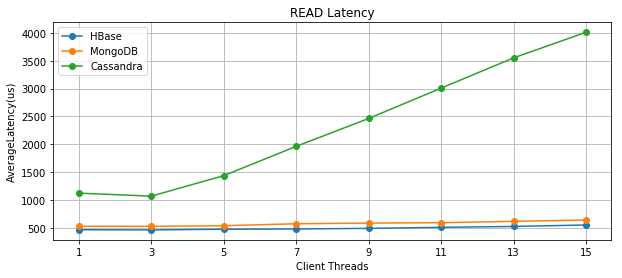

,Cassandra,HBase,MongoDB
1,1124.232577,467.268568,530.235716
3,1070.440989,464.392485,528.879208
5,1438.231006,476.581986,539.768355
7,1964.389996,481.216497,575.208308
9,2464.351170,492.236227,586.525467
11,3009.147375,510.972437,593.753021
13,3551.868488,526.550737,618.277960
15,4011.874511,553.007102,641.741107


In [19]:
df = plot_latency(hbase_workloadd_log, mongo_workloadd_log, cassa_workloadd_log, ops='READ')
df

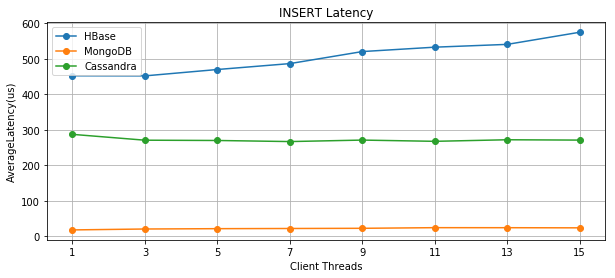

,Cassandra,HBase,MongoDB
1,287.428088,452.572532,18.099039
3,270.970007,452.248938,20.668125
5,270.161992,470.203493,21.606248
7,267.103114,486.848044,22.086655
9,271.276093,520.772775,22.641197
11,267.800393,533.136220,24.435371
13,272.193492,541.040393,24.333643
15,271.244854,575.228116,23.953995


In [20]:
df = plot_latency(hbase_workloadd_log, mongo_workloadd_log, cassa_workloadd_log, ops='INSERT')
df

### ワークロードE
Scan 95% / Insert 5% Scan Length: 10,000

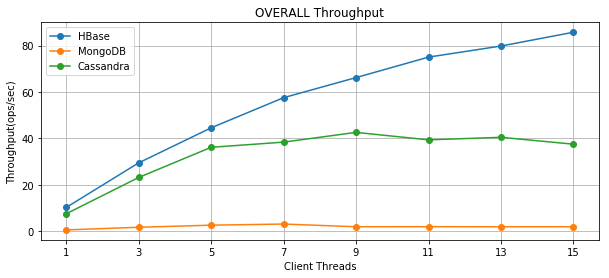

,Cassandra,HBase,MongoDB
1,7.520030,10.230838,0.566836
3,23.152221,29.448836,1.706066
5,36.153290,44.543033,2.608905
7,38.383885,57.530779,3.095639
9,42.578739,66.188784,1.931583
11,39.371164,75.008063,1.960689
13,40.452584,79.781717,1.916428
15,37.496016,85.718449,1.941946


In [21]:
df = plot_overall_throughput(hbase_workloade_log, mongo_workloade_log, cassa_workloade_log)
df

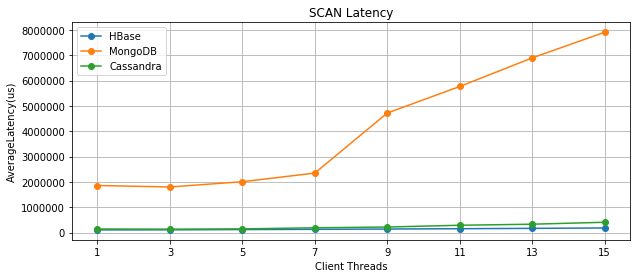

,Cassandra,HBase,MongoDB
1,139563.544077,102639.952581,1.856546e+06
3,132301.628517,106265.098083,1.798543e+06
5,142417.572421,116460.969197,2.005820e+06
7,187509.826348,125751.627713,2.347035e+06
9,216578.149968,137283.351303,4.719817e+06
11,286798.312039,150108.355382,5.766458e+06
13,328463.866603,164133.832790,6.896088e+06
15,404760.970189,179695.847656,7.908804e+06


In [22]:
df = plot_latency(hbase_workloade_log, mongo_workloade_log, cassa_workloade_log, ops='SCAN')
df

### ワークロードF
Read 50% / Read Modify Write 50%

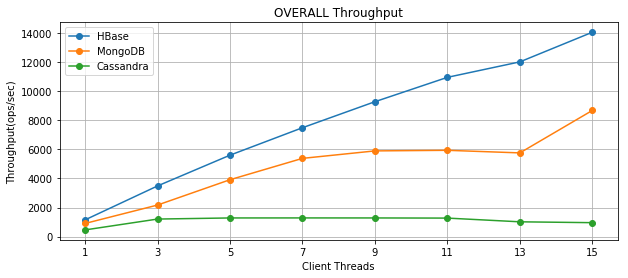

,Cassandra,HBase,MongoDB
1,460.347295,1151.312381,905.291155
3,1207.367842,3486.835453,2171.552660
5,1283.838781,5604.218856,3914.982246
7,1285.791617,7493.387086,5384.072836
9,1284.194900,9283.930445,5898.208714
11,1274.044403,10960.105217,5938.489130
13,1018.145387,12024.578238,5760.567762
15,958.878496,14063.510815,8682.515151


In [23]:
df = plot_overall_throughput(hbase_workloadf_log, mongo_workloadf_log, cassa_workloadf_log)
df

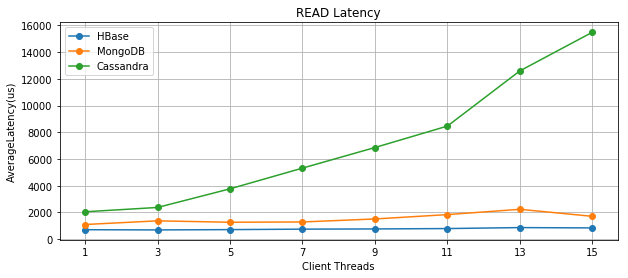

,Cassandra,HBase,MongoDB
1,2048.809831,706.794075,1095.710902
3,2372.063587,690.824442,1370.344620
5,3766.400026,713.430738,1264.677108
7,5316.637811,748.451056,1286.648755
9,6857.888378,763.906056,1510.774450
11,8463.220734,792.751601,1837.054852
13,12594.842113,864.995734,2234.192458
15,15487.053246,840.827549,1707.772674


In [24]:
df = plot_latency(hbase_workloadf_log, mongo_workloadf_log, cassa_workloadf_log, ops='READ')
df

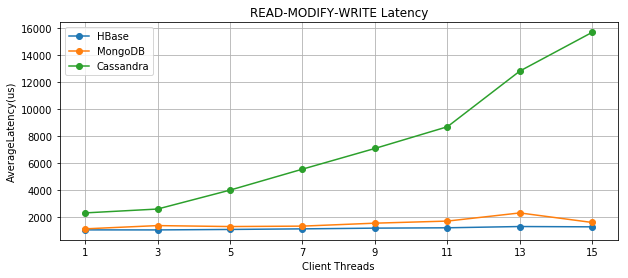

,Cassandra,HBase,MongoDB
1,2284.330586,1025.538889,1102.804455
3,2571.022426,1023.252025,1343.591192
5,3973.461909,1058.025467,1273.032894
7,5527.846956,1101.661243,1304.362349
9,7063.591225,1154.951536,1523.188433
11,8672.113936,1181.224198,1678.159302
13,12802.441904,1274.092804,2282.782836
15,15678.631938,1251.992819,1573.602651


In [25]:
df = plot_latency(hbase_workloadf_log, mongo_workloadf_log, cassa_workloadf_log, ops='READ-MODIFY-WRITE')
df

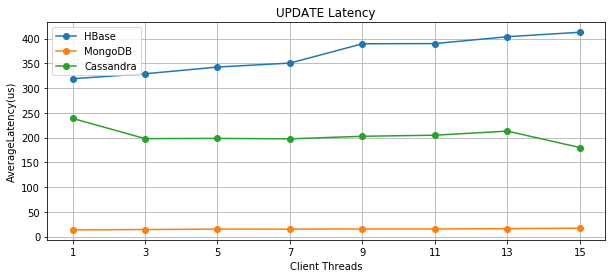

,Cassandra,HBase,MongoDB
1,238.828312,319.015845,13.525602
3,197.955735,328.937440,14.302845
5,198.393597,342.557368,15.159657
7,197.527454,350.545319,15.102360
9,202.708837,389.552983,15.429593
11,204.863766,389.971610,15.414617
13,213.136689,403.806147,16.102997
15,179.988651,412.859676,16.995916


In [26]:
df = plot_latency(hbase_workloadf_log, mongo_workloadf_log, cassa_workloadf_log, ops='UPDATE')
df

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

from scipy.interpolate import spline

In [3]:
def plot_throughput_bar(hbase_log, mongo_log, cassa_log):
    hbase_load_throughput = re.findall(r'^\[OVERALL\], Throughput\(ops/sec\), ([\d]+\.[\d]+)', hbase_log, flags=re.MULTILINE)
    mongo_load_throughput = re.findall(r'^\[OVERALL\], Throughput\(ops/sec\), ([\d]+\.[\d]+)', mongo_log, flags=re.MULTILINE)
    cassa_load_throughput = re.findall(r'^\[OVERALL\], Throughput\(ops/sec\), ([\d]+\.[\d]+)', cassa_log, flags=re.MULTILINE)

    fig = plt.figure(figsize=(10, 4))
    ax = fig.add_subplot(111)

    x = [0, 1, 2]
    y = [float(hbase_load_throughput[0]), float(mongo_load_throughput[0]), float(cassa_load_throughput[0])]
    xlabels = ['HBase', 'MongoDB', 'Cassandra']
    ax.bar(x, y, color=['blue', 'orange', 'green'], tick_label=xlabels)

    ax.set_title('Load Throughput')
    ax.set_ylabel('Throughput(ops/sec)')
    
    ax.legend()
    plt.grid()
    plt.show()

    return y

In [4]:
def plot_throughput_timeline(hbase_log, mongo_log, cassa_log):
    hbase_load_ops = re.findall(r'([\d]+) operations; ([\d]+\.[\d]+) current ops/sec; ', hbase_log, flags=re.MULTILINE)
    mongo_load_ops = re.findall(r'([\d]+) operations; ([\d]+\.[\d]+) current ops/sec; ', mongo_log, flags=re.MULTILINE)
    cassa_load_ops = re.findall(r'([\d]+) operations; ([\d]+\.[\d]+) current ops/sec; ', cassa_log, flags=re.MULTILINE)

    ops_hbase = [float(e[0]) for i, e in enumerate(hbase_load_ops) if i%2 == 0]
    ths_hbase =  [float(e[1]) for i, e in enumerate(hbase_load_ops) if i%2 == 0]

    ops_mongo = [float(e[0]) for i, e in enumerate(mongo_load_ops) if i%2 == 0]
    ths_mongo =  [float(e[1]) for i, e in enumerate(mongo_load_ops) if i%2 == 0]
    #ops_mongo_smooth = np.linspace(np.array(ops_mongo).min(), np.array(ths_mongo).max(), 1000)
    #ths_mongo_smooth = spline(ops_mongo, ths_mongo, ops_mongo_smooth)

    ops_cassa = [float(e[0]) for i, e in enumerate(cassa_load_ops) if i%2 == 0]
    ths_cassa =  [float(e[1]) for i, e in enumerate(cassa_load_ops) if i%2 == 0]
    #ops_cassa_smooth = np.linspace(np.array(ops_cassa).min(), np.array(ths_cassa).max(), 1000)
    #ths_cassa_smooth = spline(ops_cassa, ths_cassa, ops_cassa_smooth)

    fig = plt.figure(figsize=(10, 4))
    ax = fig.add_subplot(111)

    ax.plot(ops_hbase, ths_hbase, label='HBase')
    ax.plot(ops_mongo, ths_mongo, label='MongoDB')
    ax.plot(ops_cassa, ths_cassa, label='Cassandra')

    ax.set_title('Load Throughput')
    ax.set_ylabel('Throughput(ops/sec)')
    ax.set_xlabel('Operations')
    plt.xticks(range(0, 300000000, 10000000))

    for tick in ax.get_xticklabels():
        tick.set_rotation(30)

    ax.legend()
    plt.grid()
    plt.show()

In [5]:
def plot_overall_throughput(hbase_log, mongo_log, cassa_log):
    hbase_throughput = re.findall(r'^\[OVERALL\], Throughput\(ops/sec\), ([\d]+\.[\d]+)', hbase_log, flags=re.MULTILINE)
    mongo_throughput = re.findall(r'^\[OVERALL\], Throughput\(ops/sec\), ([\d]+\.[\d]+)', mongo_log, flags=re.MULTILINE)
    cassa_throughput = re.findall(r'^\[OVERALL\], Throughput\(ops/sec\), ([\d]+\.[\d]+)', cassa_log, flags=re.MULTILINE)

    threads = range(1, 16, 2)

    df = pd.DataFrame({
        'HBase': [float(d) for d in hbase_throughput],
        'MongoDB': [float(d) for d in mongo_throughput],
        'Cassandra': [float(d) for d in cassa_throughput],
    }, index=threads)

    fig = plt.figure(figsize=(10, 4))
    ax = fig.add_subplot(111)

    ax.plot(df.index, df['HBase'], marker='o', label='HBase')
    ax.plot(df.index, df['MongoDB'], marker='o', label='MongoDB')
    ax.plot(df.index, df['Cassandra'], marker='o', label='Cassandra')

    ax.set_title('OVERALL Throughput')
    ax.set_ylabel('Throughput(ops/sec)')
    ax.set_xlabel('Client Threads')
    plt.xticks(threads)

    ax.legend()
    plt.grid()
    plt.show()

    return df

In [6]:
def plot_latency(hbase_log, mongo_log, cassa_log, ops='READ'):
    hbase_read_latency = re.findall(r'^\[' + ops + '\], AverageLatency\(us\), ([\d]+\.[\d]+)', hbase_log, flags=re.MULTILINE)
    mongo_read_latency = re.findall(r'^\[' + ops + '\], AverageLatency\(us\), ([\d]+\.[\d]+)', mongo_log, flags=re.MULTILINE)
    cassa_read_latency = re.findall(r'^\[' + ops + '\], AverageLatency\(us\), ([\d]+\.[\d]+)', cassa_log, flags=re.MULTILINE)

    threads = range(1, 16, 2)

    df = pd.DataFrame({
        'HBase': [float(d) for d in hbase_read_latency],
        'MongoDB': [float(d) for d in mongo_read_latency],
        'Cassandra': [float(d) for d in cassa_read_latency]
    }, index=threads)

    fig = plt.figure(figsize=(10, 4))
    ax = fig.add_subplot(111)

    ax.plot(df.index, df['HBase'], marker='o', label='HBase')
    ax.plot(df.index, df['MongoDB'], marker='o', label='MongoDB')
    ax.plot(df.index, df['Cassandra'], marker='o', label='Cassandra')

    ax.set_title(ops + ' Latency')
    ax.set_ylabel('AverageLatency(us)')
    ax.set_xlabel('Client Threads')
    plt.xticks(threads)

    ax.legend()
    plt.grid()
    plt.show()

    return df

In [7]:
# 300m data load
hbase_load_log = open('./logs/hbase/300m_load_hbase.log').read()
mongo_load_log = open('./logs/mongo_range/300m_load_mongo.log').read()
cassa_load_log = open('./logs/cassandra/300m_load_cassandra.log').read()
# workloadA
hbase_workloada_log = open('./logs/hbase/300m1m_workloada_hbase.log').read()
mongo_workloada_log = open('./logs/mongo_range/300m1m_workloada_mongo.log').read()
cassa_workloada_log = open('./logs/cassandra/300m1m_workloada_cassandra.log').read()
# workloadB
hbase_workloadb_log = open('./logs/hbase/300m1m_workloadb_hbase.log').read()
mongo_workloadb_log = open('./logs/mongo_range/300m1m_workloadb_mongo.log').read()
cassa_workloadb_log = open('./logs/cassandra/300m1m_workloadb_cassandra.log').read()
# workloadC
hbase_workloadc_log = open('./logs/hbase/300m1m_workloadc_hbase.log').read()
mongo_workloadc_log = open('./logs/mongo_range/300m1m_workloadc_mongo.log').read()
cassa_workloadc_log = open('./logs/cassandra/300m1m_workloadc_cassandra.log').read()
# workloadD
hbase_workloadd_log = open('./logs/hbase/300m1m_workloadd_hbase.log').read()
mongo_workloadd_log = open('./logs/mongo_range/300m1m_workloadd_mongo.log').read()
cassa_workloadd_log = open('./logs/cassandra/300m1m_workloadd_cassandra.log').read()
# workloadE
hbase_workloade_log = open('./logs/hbase/300m10k_workloade_hbase.log').read()
mongo_workloade_log = open('./logs/mongo_range/300m10k_workloade_mongo.log').read()
cassa_workloade_log = open('./logs/cassandra/300m10k_workloade_cassandra.log').read()
# workloadF
hbase_workloadf_log = open('./logs/hbase/300m1m_workloadf_hbase.log').read()
mongo_workloadf_log = open('./logs/mongo_range/300m1m_workloadf_mongo.log').read()
cassa_workloadf_log = open('./logs/cassandra/300m1m_workloadf_cassandra.log').read()